# Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt


def get_roi_values(img_path, mask_path):
    """Loads a NIfTI volume, isolates voxel arrays inside a mask region, and calculates the 10th percentile."""
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extract raw HU values where the target mask segmentation is active
    roi_values = img_data[mask_data > 0]

    # Calculate the 10th percentile metric safely
    p10 = np.percentile(roi_values, 10) if len(roi_values) > 0 else np.nan
    return roi_values.flatten(), p10

# Vertebrae HU distribution

[Healthy] 10th Percentile Threshold: 278.00 HU
[MM] 10th Percentile Threshold: 97.00 HU


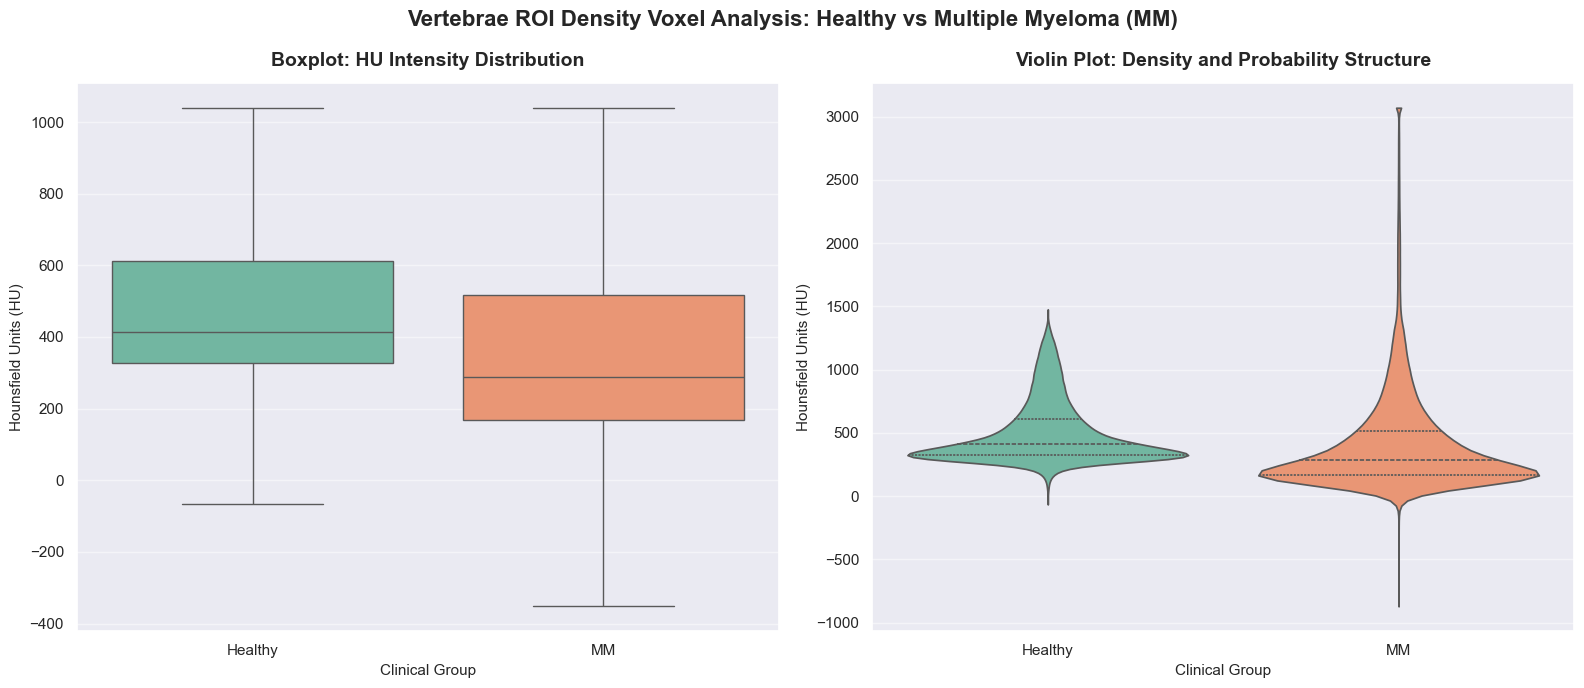

In [6]:
# 1. Path configurations
data_config = [
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_spine_seg.nii.gz",
        "label": "Healthy"
    },
    {
        "img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
        "mask": r"E:\DATA_Myelomy\Myel_001\myel_001_spine_seg.nii.gz",
        "label": "MM"
    }
]

extracted_rows = []
p10_metrics_map = {}

# ==============================================================================
# 2. DATA EXTRACTION & DATAFRAME CONSTRUCTION (Fixed Row Unrolling)
# ==============================================================================
for profile in data_config:
    hu_values, p10 = get_roi_values(profile['img'], profile['mask'])

    # Store calculated statistic for custom graph overlays
    p10_metrics_map[profile['label']] = p10
    print(f"[{profile['label']}] 10th Percentile Threshold: {p10:.2f} HU")

    # Force explicit unrolling into scalar rows by converting to list or a clean Series
    temp_df = pd.DataFrame({
        'HU': hu_values,
        'Group': profile['label']
    })
    extracted_rows.append(temp_df)

# Combine into a single master long-format DataFrame for Seaborn
plot_df = pd.concat(extracted_rows, ignore_index=True)

# Double-check data types to prevent mixed object assignments
plot_df['HU'] = pd.to_numeric(plot_df['HU'], errors='coerce')
plot_df['Group'] = plot_df['Group'].astype(str)

# ==============================================================================
# 3. HIGH-DENSITY VISUALIZATION PIPELINE (Side-by-Side Analysis)
# ==============================================================================
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Explicit cohort ordering and palette definitions
group_order = ["Healthy", "MM"]
color_palette = {"Healthy": "#66c2a5", "MM": "#fc8d62"}

# --------------------------------------------------------------------------
# SUBPLOT 1: Boxplot (Quantile Range Distribution Profile)
# --------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x='Group',
    y='HU',
    order=group_order,
    hue='Group',
    palette=color_palette,
    showfliers=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Boxplot: HU Intensity Distribution', fontsize=14, pad=12, fontweight='bold')
ax1.set_xlabel('Clinical Group', fontsize=11)
ax1.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# --------------------------------------------------------------------------
# SUBPLOT 2: Violin Plot (Probability Density Profile)
# --------------------------------------------------------------------------
sns.violinplot(
    data=plot_df,
    x='Group',
    y='HU',
    order=group_order,
    hue='Group',
    palette=color_palette,
    inner="quartile",
    cut=0,
    legend=False,
    ax=ax2
)
ax2.set_title('Violin Plot: Density and Probability Structure', fontsize=14, pad=12, fontweight='bold')
ax2.set_xlabel('Clinical Group', fontsize=11)
ax2.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Supertitle and formatting configurations in English
plt.suptitle('Vertebrae ROI Density Voxel Analysis: Healthy vs Multiple Myeloma (MM)', fontsize=16, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()

# Liver segment HU distribution

[Healthy 10] 10th Percentile Threshold: 12.00 HU
[MM Stage 1] 10th Percentile Threshold: -12.00 HU


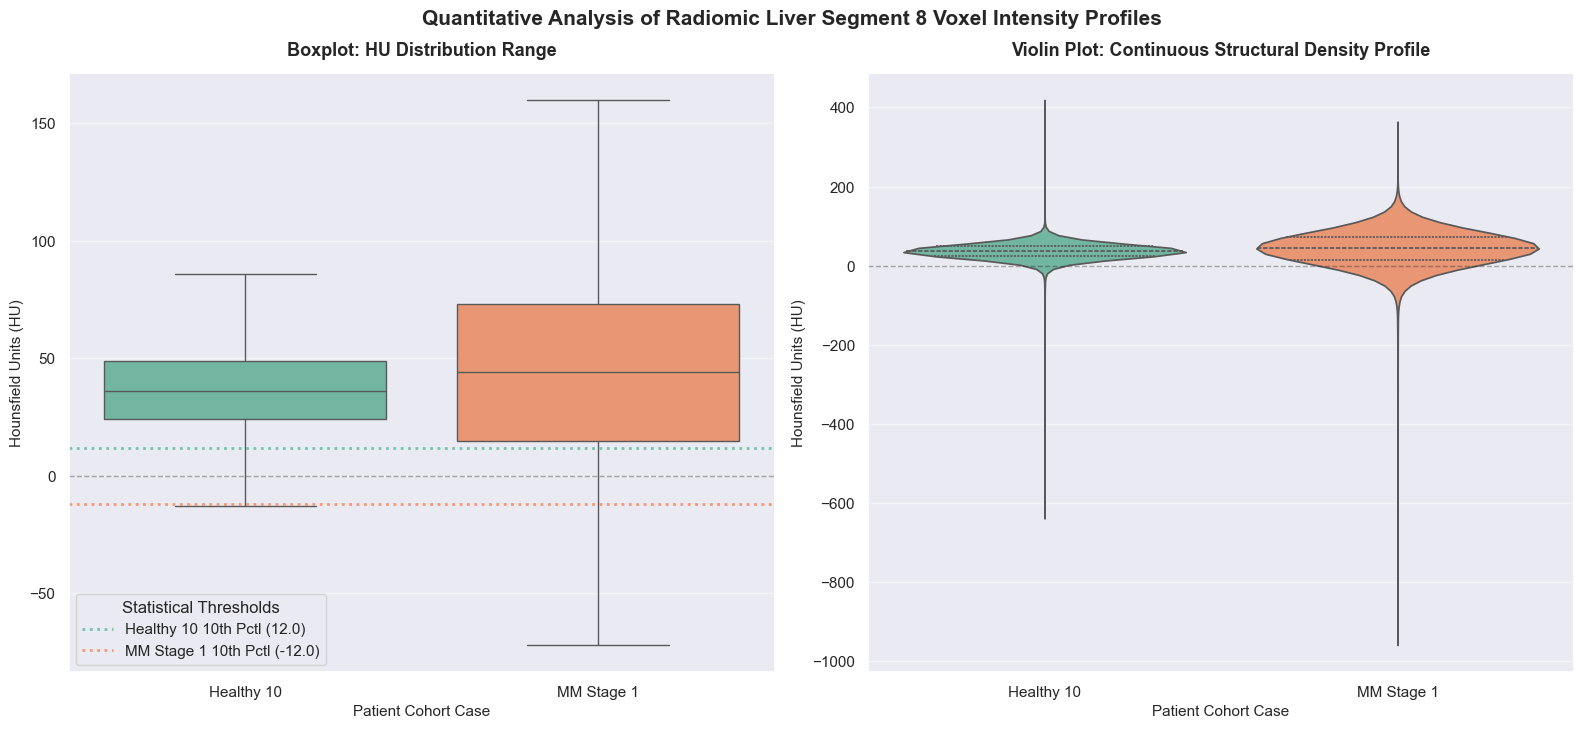

In [7]:
# 1. Path configurations (Standardized text labels to English)
data_config = [
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\liver_segment_8.nii.gz",
        "label": "Healthy 10"
    },
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\liver_segment_8.nii.gz",
        "label": "MM Stage 1"
    }
]

extracted_records = []
p10_metrics_map = {}

# ==============================================================================
# 2. FILE EXTRACTION & ANALYSIS
# ==============================================================================
for profile in data_config:
    voxel_intensities, computed_p10 = get_roi_values(profile['img'], profile['mask'])

    # Store calculated statistic for custom graph overlays
    p10_metrics_map[profile['label']] = computed_p10
    print(f"[{profile['label']}] 10th Percentile Threshold: {computed_p10:.2f} HU")

    # Group measurements inside a structural data frame block
    temp_df = pd.DataFrame({
        'HU': voxel_intensities,
        'Cohort': profile['label']
    })
    extracted_records.append(temp_df)

# Assemble individual components into a single primary plotting frame
plot_df = pd.concat(extracted_records, ignore_index=True)

# ==============================================================================
# 3. GRAPHICAL GRID PIPELINE GENERATION
# ==============================================================================
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

cohort_order = [p['label'] for p in data_config]
palette_colors = {"Healthy 10": "#66c2a5", "MM Stage 1": "#fc8d62"}

# --------------------------------------------------------------------------
# SUBPLOT 1: Boxplot (Quantile Range Outlines)
# --------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    showfliers=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Boxplot: HU Distribution Range', fontsize=13, pad=12, fontweight='bold')
ax1.set_xlabel('Patient Cohort Case', fontsize=11)
ax1.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Superimpose specific 10th percentile horizontal markers per case column
for class_idx, class_label in enumerate(cohort_order):
    stat_val = p10_metrics_map[class_label]
    if not np.isnan(stat_val):
        ax1.axhline(
            y=stat_val,
            color=palette_colors[class_label],
            linestyle=':',
            linewidth=2,
            alpha=0.9,
            label=f"{class_label} 10th Pctl ({stat_val:.1f})"
        )
ax1.legend(title="Statistical Thresholds", loc="lower left")

# --------------------------------------------------------------------------
# SUBPLOT 2: Violin Plot (Probability Density Outlines)
# --------------------------------------------------------------------------
sns.violinplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    inner="quartile",
    cut=0,
    legend=False,
    ax=ax2
)
ax2.set_title('Violin Plot: Continuous Structural Density Profile', fontsize=13, pad=12, fontweight='bold')
ax2.set_xlabel('Patient Cohort Case', fontsize=11)
ax2.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Add a subtle baseline context reference at 0 HU (Water density benchmark)
for ax in (ax1, ax2):
    ax.axhline(0, color='#2b2b2b', linestyle='--', linewidth=1, alpha=0.4)

# Formulate titles and layouts in English
plt.suptitle('Quantitative Analysis of Radiomic Liver Segment 8 Voxel Intensity Profiles', fontsize=15, y=0.97, fontweight='bold')
plt.tight_layout()
plt.show()

# Fat HU distribution

[Healthy 10] 10th Percentile Threshold: -133.00 HU
[MM Stage 1 (Pt 3)] 10th Percentile Threshold: -141.00 HU


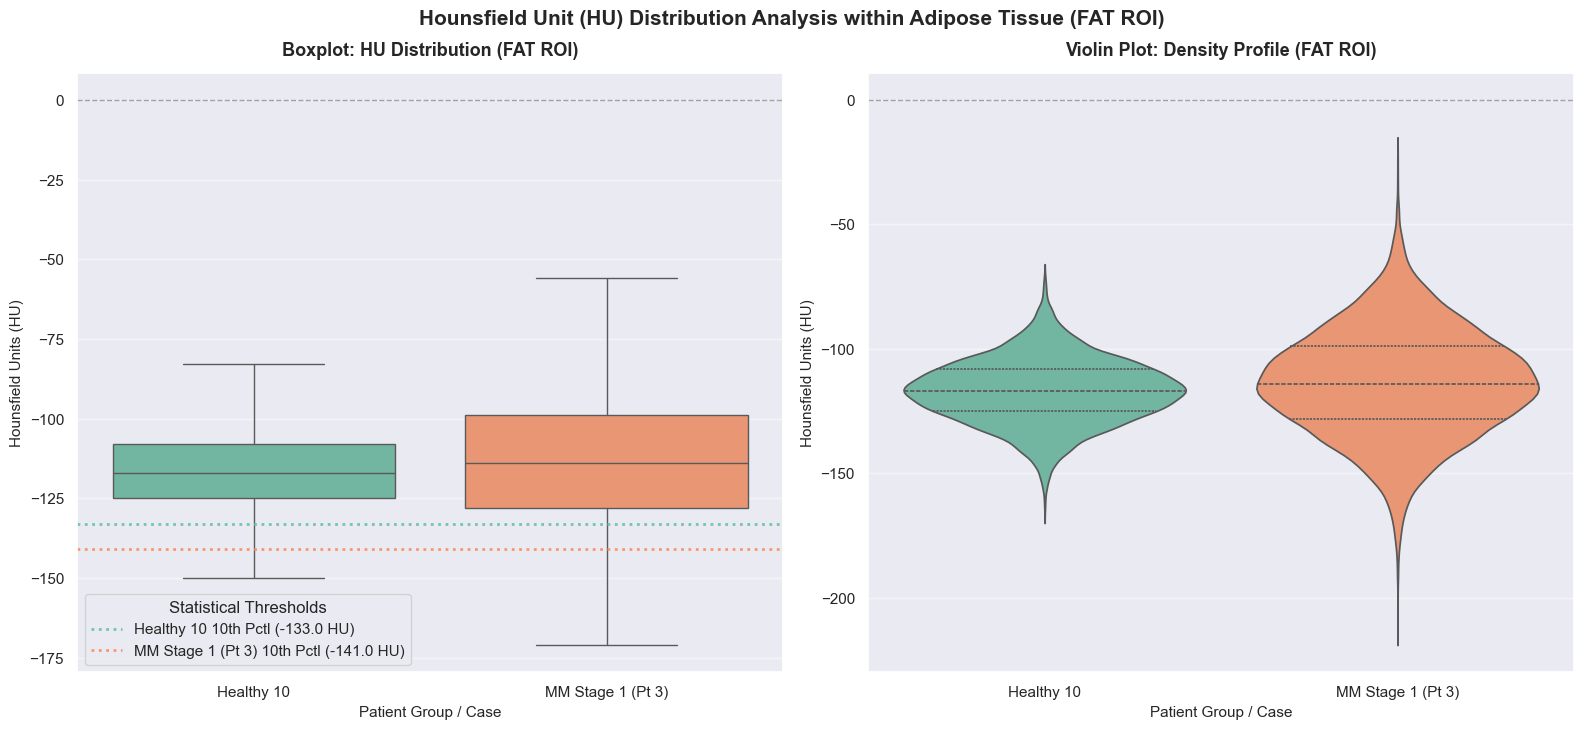

In [8]:
# 1. Path configurations (Standardized text labels for clinical accuracy)
data_config = [
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_fat_segment.nii.gz",
        "label": "Healthy 10"
    },
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_fat_segment.nii.gz",
        "label": "MM Stage 1 (Pt 3)"
    }
]

extracted_records = []
p10_metrics_map = {}

# ==============================================================================
# 2. DATA LOAD & CALCULATIONS LOOP
# ==============================================================================
for profile in data_config:
    voxel_intensities, computed_p10 = get_roi_values(profile['img'], profile['mask'])

    # Store calculated statistic for personalized chart indicator lines
    p10_metrics_map[profile['label']] = computed_p10
    print(f"[{profile['label']}] 10th Percentile Threshold: {computed_p10:.2f} HU")

    # Structure data to build a long-format DataFrame
    temp_df = pd.DataFrame({
        'HU': voxel_intensities,
        'Cohort': profile['label']
    })
    extracted_records.append(temp_df)

# Merge rows cleanly into a unified master frame
plot_df = pd.concat(extracted_records, ignore_index=True)

# ==============================================================================
# 3. SIDE-BY-SIDE GRAPH PLOTTING PIPELINE
# ==============================================================================
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

cohort_order = [p['label'] for p in data_config]
palette_colors = {"Healthy 10": "#66c2a5", "MM Stage 1 (Pt 3)": "#fc8d62"}

# --------------------------------------------------------------------------
# SUBPLOT 1: Boxplot (Quantile Range Range Distribution Profile)
# --------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    showfliers=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Boxplot: HU Distribution (FAT ROI)', fontsize=13, pad=12, fontweight='bold')
ax1.set_xlabel('Patient Group / Case', fontsize=11)
ax1.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Superimpose the actual computed 10th percentile horizontal markers
for class_label in cohort_order:
    stat_val = p10_metrics_map[class_label]
    if not np.isnan(stat_val):
        ax1.axhline(
            y=stat_val,
            color=palette_colors[class_label],
            linestyle=':',
            linewidth=2,
            alpha=0.9,
            label=f"{class_label} 10th Pctl ({stat_val:.1f} HU)"
        )
ax1.legend(title="Statistical Thresholds", loc="lower left")

# --------------------------------------------------------------------------
# SUBPLOT 2: Violin Plot (Continuous Density Distribution Profile)
# --------------------------------------------------------------------------
sns.violinplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    inner="quartile",
    cut=0,
    legend=False,
    ax=ax2
)
ax2.set_title('Violin Plot: Density Profile (FAT ROI)', fontsize=13, pad=12, fontweight='bold')
ax2.set_xlabel('Patient Group / Case', fontsize=11)
ax2.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Add a standard dashed context reference line at 0 HU (Water density reference)
for ax in (ax1, ax2):
    ax.axhline(0, color='#2b2b2b', linestyle='--', linewidth=1, alpha=0.4)

# Formulate headers, titles and adjust layout dimensions completely in English
plt.suptitle('Hounsfield Unit (HU) Distribution Analysis within Adipose Tissue (FAT ROI)', fontsize=15, y=0.97, fontweight='bold')
plt.tight_layout()
plt.show()

# Muscle HU distribution

[Healthy 10] 10th Percentile Threshold: 42.00 HU
[MM Stage 1 (Pt 3)] 10th Percentile Threshold: 15.00 HU


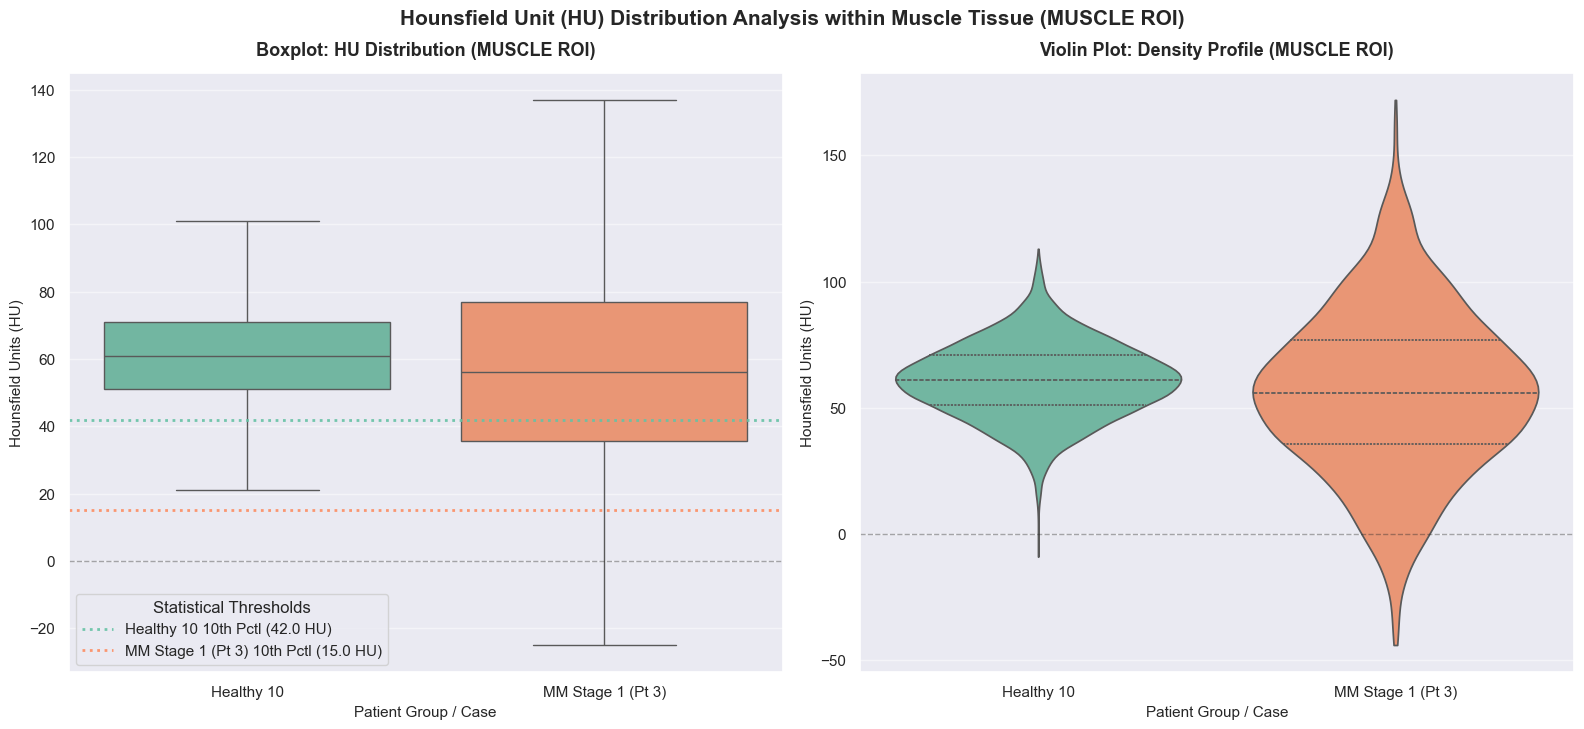

In [9]:
# 1. Path configurations (Standardized text labels for cohort uniformity)
data_config = [
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_muscle_segment.nii.gz",
        "label": "Healthy 10"
    },
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_muscle_segment.nii.gz",
        "label": "MM Stage 1 (Pt 3)"
    }
]

extracted_records = []
p10_metrics_map = {}

# ==============================================================================
# 2. DATA LOAD & CALCULATIONS LOOP
# ==============================================================================
for profile in data_config:
    voxel_intensities, computed_p10 = get_roi_values(profile['img'], profile['mask'])

    # Store calculated statistic for personalized chart indicator lines
    p10_metrics_map[profile['label']] = computed_p10
    print(f"[{profile['label']}] 10th Percentile Threshold: {computed_p10:.2f} HU")

    # Structure data to build a long-format DataFrame
    temp_df = pd.DataFrame({
        'HU': voxel_intensities,
        'Cohort': profile['label']
    })
    extracted_records.append(temp_df)

# Merge individual frames cleanly into a unified master frame
plot_df = pd.concat(extracted_records, ignore_index=True)

# ==============================================================================
# 3. SIDE-BY-SIDE GRAPH PLOTTING PIPELINE
# ==============================================================================
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

cohort_order = [p['label'] for p in data_config]
palette_colors = {"Healthy 10": "#66c2a5", "MM Stage 1 (Pt 3)": "#fc8d62"}

# --------------------------------------------------------------------------
# SUBPLOT 1: Boxplot (Quantile Range Range Distribution Profile)
# --------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    showfliers=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Boxplot: HU Distribution (MUSCLE ROI)', fontsize=13, pad=12, fontweight='bold')
ax1.set_xlabel('Patient Group / Case', fontsize=11)
ax1.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Superimpose the actual computed 10th percentile horizontal markers
for class_label in cohort_order:
    stat_val = p10_metrics_map[class_label]
    if not np.isnan(stat_val):
        ax1.axhline(
            y=stat_val,
            color=palette_colors[class_label],
            linestyle=':',
            linewidth=2,
            alpha=0.9,
            label=f"{class_label} 10th Pctl ({stat_val:.1f} HU)"
        )
ax1.legend(title="Statistical Thresholds", loc="lower left")

# --------------------------------------------------------------------------
# SUBPLOT 2: Violin Plot (Continuous Density Distribution Profile)
# --------------------------------------------------------------------------
sns.violinplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    inner="quartile",
    cut=0,
    legend=False,
    ax=ax2
)
ax2.set_title('Violin Plot: Density Profile (MUSCLE ROI)', fontsize=13, pad=12, fontweight='bold')
ax2.set_xlabel('Patient Group / Case', fontsize=11)
ax2.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Add a standard dashed context reference line at 0 HU (Water density benchmark)
for ax in (ax1, ax2):
    ax.axhline(0, color='#2b2b2b', linestyle='--', linewidth=1, alpha=0.4)

# Set headers, titles, and layout spaces fully in English
plt.suptitle('Hounsfield Unit (HU) Distribution Analysis within Muscle Tissue (MUSCLE ROI)', fontsize=15, y=0.97, fontweight='bold')
plt.tight_layout()
plt.show()

# Background HU distribution

[Healthy 1] 10th Percentile Threshold: -1011.00 HU
[MM Stage 1] 10th Percentile Threshold: -1024.00 HU


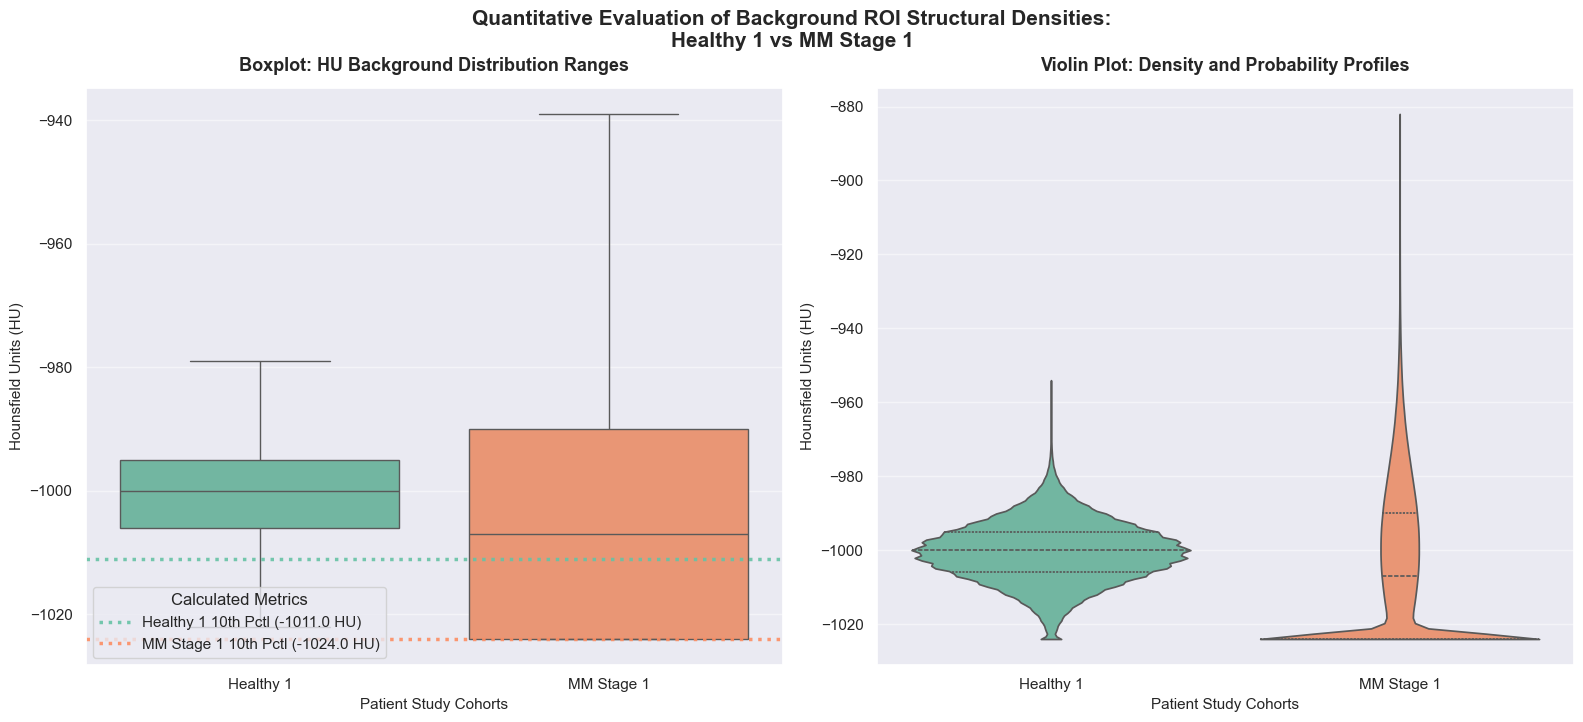

In [4]:
def get_background_roi_data(p_cfg):
    """Loads a 3D NIfTI volume and extracts flattened voxel values within a specified bounding box."""
    img = nib.load(p_cfg['img']).get_fdata()

    # Extract structural 3D bounding box array matching the coordinate configurations
    vals = img[
        p_cfg['x_range'][0]:p_cfg['x_range'][1],
        p_cfg['y_range'][0]:p_cfg['y_range'][1],
        p_cfg['z_range'][0]:p_cfg['z_range'][1]
    ].flatten()

    # Calculate 10th percentile threshold
    p10 = np.percentile(vals, 10) if len(vals) > 0 else np.nan
    return vals, p10


# ==============================================================================
# 1. COHORT PATHWAY & COORDINATE CONFIGURATION
# ==============================================================================
p1_config = {
    "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_001\healthy_001_konv.nii.gz",
    "label": "Healthy 1",
    "x_range": (100, 200), "y_range": (400, 500), "z_range": (100, 300)
}

p2_config = {
    "img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
    "label": "MM Stage 1",
    "x_range": (100, 300), "y_range": (460, 500), "z_range": (550, 750)
}

# ==============================================================================
# 2. DATA EXTRACTION & RECORD PROCESSING
# ==============================================================================
v1_data, p10_1 = get_background_roi_data(p1_config)
print(f"[{p1_config['label']}] 10th Percentile Threshold: {p10_1:.2f} HU")

v2_data, p10_2 = get_background_roi_data(p2_config)
print(f"[{p2_config['label']}] 10th Percentile Threshold: {p10_2:.2f} HU")

# Restructure extracted flattened metrics into a standardized long-format DataFrame
df_v1 = pd.DataFrame({'HU': v1_data, 'Cohort': p1_config['label']})
df_v2 = pd.DataFrame({'HU': v2_data, 'Cohort': p2_config['label']})
plot_df = pd.concat([df_v1, df_v2], ignore_index=True)

# ==============================================================================
# 3. STATISTICAL DENSITY ANALYSIS PLOTTING PIPELINE
# ==============================================================================
sns.set_theme(style="darkgrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7.5))

cohort_order = [p1_config['label'], p2_config['label']]
palette_colors = {p1_config['label']: "#66c2a5", p2_config['label']: "#fc8d62"}
p10_map = {p1_config['label']: p10_1, p2_config['label']: p10_2}

# --------------------------------------------------------------------------
# SUBPLOT 1: Boxplot (Quantile Structural Range Profiling)
# --------------------------------------------------------------------------
sns.boxplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    showfliers=False,
    legend=False,
    ax=ax1
)
ax1.set_title('Boxplot: HU Background Distribution Ranges', fontsize=13, pad=12, fontweight='bold')
ax1.set_xlabel('Patient Study Cohorts', fontsize=11)
ax1.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Dynamically overlay specific calculated 10th percentile indicator reference lines
for target_cohort in cohort_order:
    stat_val = p10_map[target_cohort]
    if not np.isnan(stat_val):
        ax1.axhline(
            y=stat_val,
            color=palette_colors[target_cohort],
            linestyle=':',
            linewidth=2.5,
            alpha=0.9,
            label=f"{target_cohort} 10th Pctl ({stat_val:.1f} HU)"
        )
ax1.legend(title="Calculated Metrics", loc="lower left")

# --------------------------------------------------------------------------
# SUBPLOT 2: Violin Plot (Continuous Voxel Density Structural Probability)
# --------------------------------------------------------------------------
sns.violinplot(
    data=plot_df,
    x='Cohort',
    y='HU',
    order=cohort_order,
    hue='Cohort',
    palette=palette_colors,
    inner="quartile",
    cut=0,
    legend=False,
    ax=ax2
)
ax2.set_title('Violin Plot: Density and Probability Profiles', fontsize=13, pad=12, fontweight='bold')
ax2.set_xlabel('Patient Study Cohorts', fontsize=11)
ax2.set_ylabel('Hounsfield Units (HU)', fontsize=11)

# Global canvas packing configuration
plt.suptitle(
    f"Quantitative Evaluation of Background ROI Structural Densities:\n"
    f"{p1_config['label']} vs {p2_config['label']}",
    fontsize=15, y=0.96, fontweight='bold'
)
plt.tight_layout()
plt.show()